# 09. 불량 메커니즘 규명 (Defect Mechanism Analysis)

WM-811K 데이터셋의 9가지 불량 패턴에 대해 **물리적 원인을 규명**합니다.

- 공간 분포 정량화로 메커니즘 주장을 데이터로 증명
- `configs/defect_metadata.json` 생성 (Step 10~12 재사용)
- `src/defect_analyzer.py` 구현
- `docs/defect_mechanism_analysis.md` 리포트 저장

## 1. 환경 설정

In [16]:
import warnings
warnings.filterwarnings('ignore')

import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats

# ── 경로 설정 ──
ROOT = Path(os.getcwd())
DATA_PATH      = ROOT / 'data' / 'raw' / 'LSWMD.pkl'
PROCESSED_DIR  = ROOT / 'data' / 'processed'
MAPS_PATH      = PROCESSED_DIR / 'all_maps_resized.npy'
SPLIT_PATH     = PROCESSED_DIR / 'split_indices.pkl'
CONFIGS_DIR    = ROOT / 'configs'
ANALYSIS_DIR   = ROOT / 'analysis'
DOCS_DIR       = ROOT / 'docs'
SRC_DIR        = ROOT / 'src'

for d in [CONFIGS_DIR, ANALYSIS_DIR, DOCS_DIR, SRC_DIR]:
    d.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)

CLASS_NAMES = ['none', 'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
               'Loc', 'Near-full', 'Random', 'Scratch']

print(f'ROOT: {ROOT}')
print(f'데이터 파일 존재: {DATA_PATH.exists()}')
print(f'전처리 맵 존재: {MAPS_PATH.exists()}')
# ── matplotlib 한글 폰트 설정 (Windows: Malgun Gothic) ──
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False


ROOT: c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석
데이터 파일 존재: True
전처리 맵 존재: True


## 2. 데이터 로드 & 클래스 분포 확인

In [17]:
# ── 원본 데이터 로드 ──
df = pd.read_pickle(DATA_PATH)

def extract_label(x):
    """failureType 컬럼은 numpy ndarray([[label]]) 형태로 저장됨"""
    if isinstance(x, (list, np.ndarray)):
        if len(x) == 0:
            return 'unknown'
        inner = x[0]
        if isinstance(inner, (list, np.ndarray)):
            return str(inner[0]) if len(inner) > 0 else 'unknown'
        return str(inner)
    return str(x)

df['failureType_clean'] = df['failureType'].apply(extract_label)
df_labeled = df[df['failureType_clean'] != 'none_of_the_above'].copy()
# 실제 레이블만 (unknown 제외)
valid_classes = CLASS_NAMES
df_valid = df[df['failureType_clean'].isin(valid_classes)].copy()

class_counts = df_valid['failureType_clean'].value_counts()
print(f'레이블 유효 샘플: {len(df_valid):,}개')
print('\n클래스 분포:')
for cls, cnt in class_counts.items():
    print(f'  {cls:<12} {cnt:>7,}개  ({cnt/len(df_valid)*100:.2f}%)')


레이블 유효 샘플: 172,950개

클래스 분포:
  none         147,431개  (85.24%)
  Edge-Ring      9,680개  (5.60%)
  Edge-Loc       5,189개  (3.00%)
  Center         4,294개  (2.48%)
  Loc            3,593개  (2.08%)
  Scratch        1,193개  (0.69%)
  Random           866개  (0.50%)
  Donut            555개  (0.32%)
  Near-full        149개  (0.09%)


In [18]:
# ── 전처리된 64x64 맵 로드 ──
all_maps = np.load(MAPS_PATH)  # (172950, 64, 64) uint8

# 레이블 재생성 (전처리 시와 동일 순서)
df_valid_reset = df_valid.reset_index(drop=True)

# split_indices 로드 (키 이름 유연하게 처리)
with open(SPLIT_PATH, 'rb') as f:
    split_indices = pickle.load(f)

train_idx = split_indices.get('train_idx', split_indices.get('train', np.array([])))
val_idx   = split_indices.get('val_idx',   split_indices.get('val',   np.array([])))
test_idx  = split_indices.get('test_idx',  split_indices.get('test',  np.array([])))
all_indices = np.concatenate([train_idx, val_idx, test_idx])

# 클래스별 맵 인덱스 구성
labels_array = df_valid_reset['failureType_clean'].values
class_indices = {cls: np.where(labels_array == cls)[0] for cls in CLASS_NAMES}

print(f'all_maps shape: {all_maps.shape}')
for cls, idx in class_indices.items():
    print(f'  {cls:<12}: {len(idx):>7,}개')


all_maps shape: (172950, 64, 64)
  none        : 147,431개
  Center      :   4,294개
  Donut       :     555개
  Edge-Loc    :   5,189개
  Edge-Ring   :   9,680개
  Loc         :   3,593개
  Near-full   :     149개
  Random      :     866개
  Scratch     :   1,193개


## 3. 불량 패턴별 샘플 이미지 갤러리

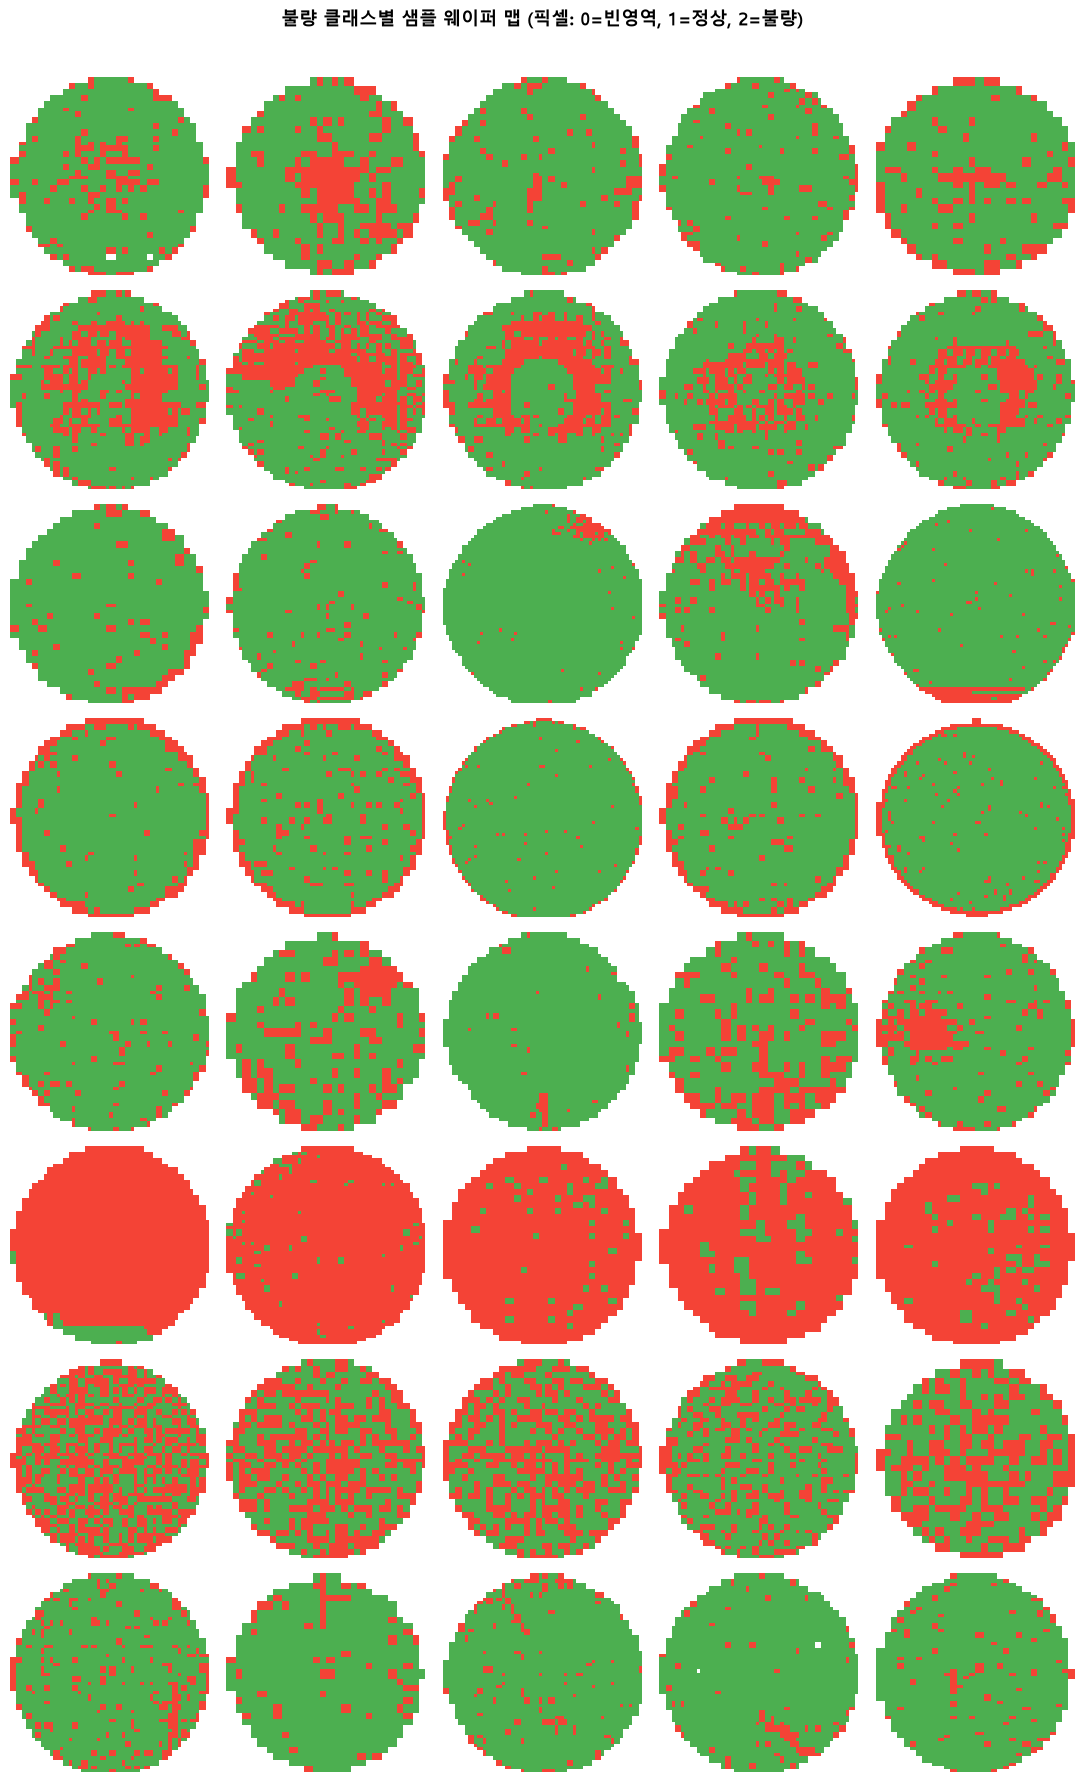

저장: analysis/defect_sample_gallery.png


In [19]:
DEFECT_CLASSES = [c for c in CLASS_NAMES if c != 'none']
N_SAMPLES = 5

fig, axes = plt.subplots(len(DEFECT_CLASSES), N_SAMPLES,
                          figsize=(N_SAMPLES * 2.2, len(DEFECT_CLASSES) * 2.2))
fig.suptitle('불량 클래스별 샘플 웨이퍼 맵 (픽셀: 0=빈영역, 1=정상, 2=불량)',
             fontsize=13, fontweight='bold', y=1.01)

cmap = plt.cm.colors.ListedColormap(['white', '#4CAF50', '#F44336'])

for row, cls in enumerate(DEFECT_CLASSES):
    idxs = class_indices[cls]
    sample_idxs = np.random.choice(idxs, min(N_SAMPLES, len(idxs)), replace=False)
    for col, idx in enumerate(sample_idxs):
        ax = axes[row, col]
        ax.imshow(all_maps[idx], cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold', rotation=0,
                          labelpad=60, va='center')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'defect_sample_gallery.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장: analysis/defect_sample_gallery.png')

## 4. 공간 분포 정량화 — 메커니즘 증거 데이터

In [20]:
def compute_spatial_metrics(maps_subset):
    """클래스별 공간 분포 지표 계산"""
    H, W = 64, 64
    cy, cx = H // 2, W // 2

    # 거리 마스크
    y_idx, x_idx = np.mgrid[0:H, 0:W]
    dist = np.sqrt((y_idx - cy)**2 + (x_idx - cx)**2)
    max_dist = np.sqrt(cy**2 + cx**2)

    center_mask = dist <= max_dist * 0.35   # 중심 35%
    edge_mask   = dist >= max_dist * 0.75   # 외곽 25%
    ring_mask   = (dist >= max_dist * 0.55) & (dist < max_dist * 0.75)  # 링

    defect_pixels = (maps_subset == 2).astype(float)  # (N,64,64)
    total_defect  = defect_pixels.sum(axis=(1, 2)) + 1e-8

    center_ratio = (defect_pixels * center_mask).sum(axis=(1, 2)) / total_defect
    edge_ratio   = (defect_pixels * edge_mask).sum(axis=(1, 2))   / total_defect
    ring_ratio   = (defect_pixels * ring_mask).sum(axis=(1, 2))   / total_defect

    valid_pixels = (maps_subset > 0).astype(float)
    defect_density = defect_pixels.sum(axis=(1,2)) / (valid_pixels.sum(axis=(1,2)) + 1e-8)

    # 공간 엔트로피 (균등 분포일수록 높음)
    mean_map = defect_pixels.mean(axis=0).flatten() + 1e-10
    mean_map /= mean_map.sum()
    entropy = float(-np.sum(mean_map * np.log(mean_map)))

    return {
        'center_ratio':   float(center_ratio.mean()),
        'edge_ratio':     float(edge_ratio.mean()),
        'ring_ratio':     float(ring_ratio.mean()),
        'defect_density': float(defect_density.mean()),
        'spatial_entropy': entropy,
        'n_samples':      len(maps_subset)
    }

spatial_stats = {}
for cls in CLASS_NAMES:
    idxs = class_indices[cls]
    sample = all_maps[idxs] if len(idxs) <= 2000 else all_maps[np.random.choice(idxs, 2000, replace=False)]
    spatial_stats[cls] = compute_spatial_metrics(sample)

df_spatial = pd.DataFrame(spatial_stats).T
print('클래스별 공간 분포 지표:')
print(df_spatial.round(4).to_string())

클래스별 공간 분포 지표:
           center_ratio  edge_ratio  ring_ratio  defect_density  spatial_entropy  n_samples
none             0.1976         0.0      0.5442          0.1054           8.0284     2000.0
Center           0.3719         0.0      0.4082          0.2330           7.9408     2000.0
Donut            0.4455         0.0      0.2513          0.2760           7.9129      555.0
Edge-Loc         0.1510         0.0      0.6212          0.1791           8.0178     2000.0
Edge-Ring        0.0950         0.0      0.7805          0.1533           7.5731     2000.0
Loc              0.2388         0.0      0.4576          0.1512           8.0823     2000.0
Near-full        0.2598         0.0      0.3756          0.8765           8.0917      149.0
Random           0.2589         0.0      0.4084          0.4799           8.1011      866.0
Scratch          0.1999         0.0      0.5319          0.1003           8.0569     1193.0


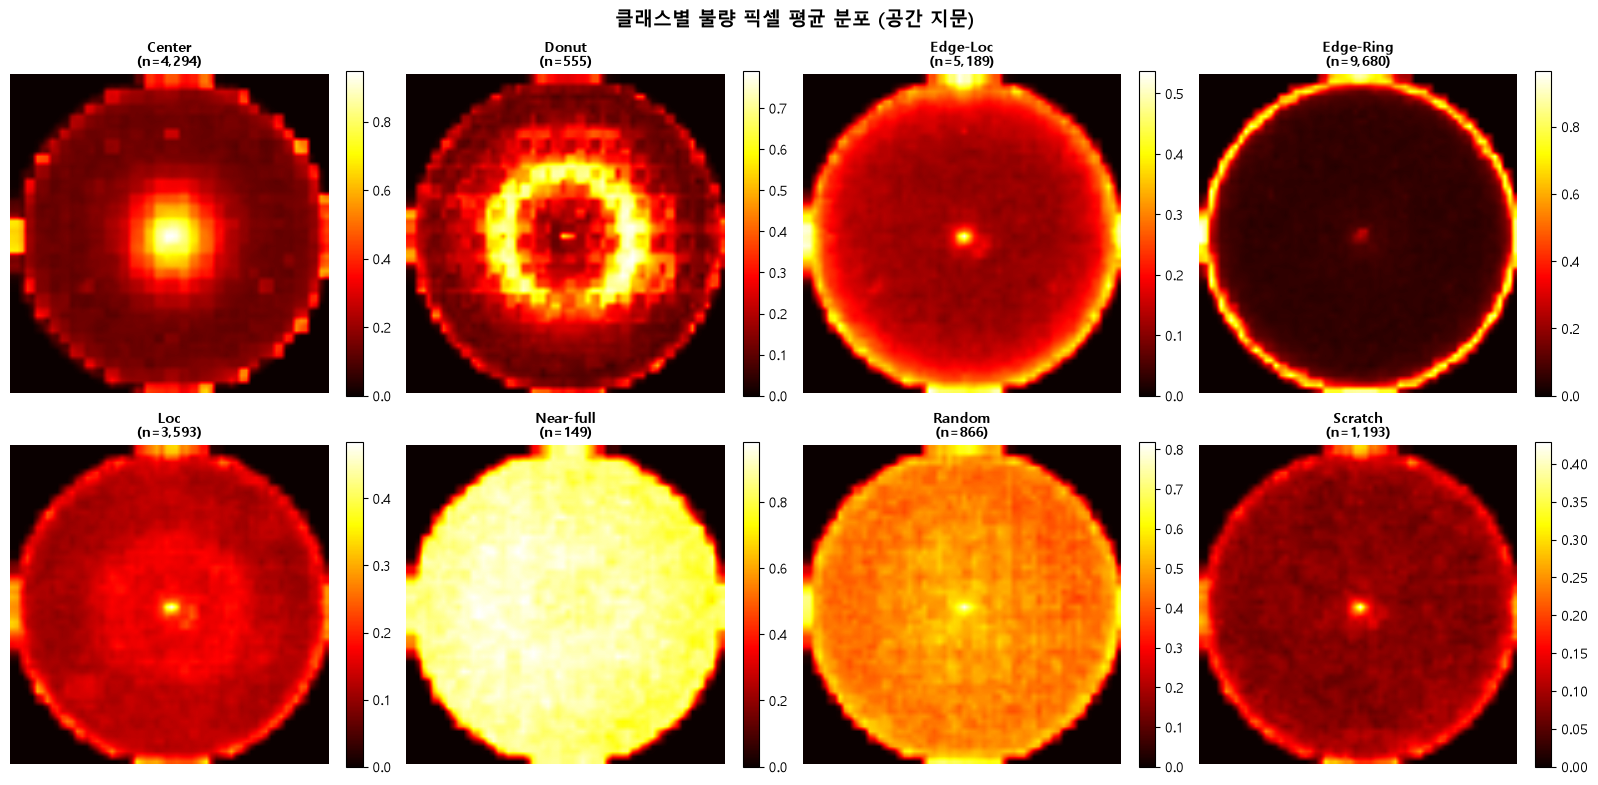

저장: analysis/defect_spatial_heatmaps.png


In [21]:
# ── 클래스별 평균 히트맵 (공간 지문) ──
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('클래스별 불량 픽셀 평균 분포 (공간 지문)', fontsize=14, fontweight='bold')

for i, cls in enumerate(DEFECT_CLASSES):
    ax = axes[i // 4, i % 4]
    idxs = class_indices[cls]
    sample = all_maps[idxs] if len(idxs) <= 2000 else all_maps[np.random.choice(idxs, 2000, replace=False)]
    defect_map = (sample == 2).astype(float).mean(axis=0)
    im = ax.imshow(defect_map, cmap='hot', interpolation='bilinear')
    ax.set_title(f'{cls}\n(n={len(idxs):,})', fontsize=10, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

# 마지막 빈 칸 숨김
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'defect_spatial_heatmaps.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장: analysis/defect_spatial_heatmaps.png')

## 5. 공간 분포 비교 시각화

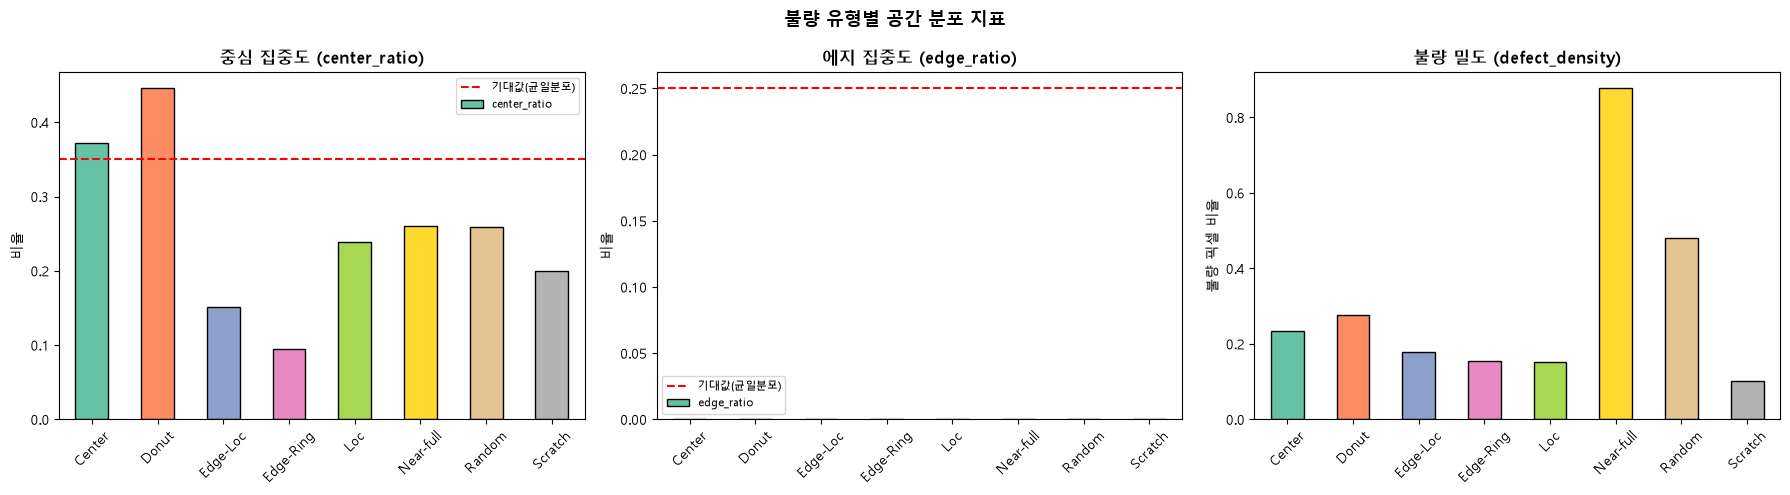

저장: analysis/spatial_distribution_metrics.png


In [22]:
df_plot = df_spatial.loc[DEFECT_CLASSES].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('불량 유형별 공간 분포 지표', fontsize=13, fontweight='bold')

colors = sns.color_palette('Set2', len(DEFECT_CLASSES))

# center_ratio
df_plot['center_ratio'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('중심 집중도 (center_ratio)', fontweight='bold')
axes[0].set_ylabel('비율')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(0.35, color='red', linestyle='--', label='기대값(균일분포)')
axes[0].legend(fontsize=8)

# edge_ratio
df_plot['edge_ratio'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('에지 집중도 (edge_ratio)', fontweight='bold')
axes[1].set_ylabel('비율')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0.25, color='red', linestyle='--', label='기대값(균일분포)')
axes[1].legend(fontsize=8)

# defect_density
df_plot['defect_density'].plot(kind='bar', ax=axes[2], color=colors, edgecolor='black')
axes[2].set_title('불량 밀도 (defect_density)', fontweight='bold')
axes[2].set_ylabel('불량 픽셀 비율')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'spatial_distribution_metrics.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장: analysis/spatial_distribution_metrics.png')

## 6. 불량 메커니즘 정의 (9가지 물리적 원인)

In [23]:
# ── 9가지 불량 메커니즘 정의 ──
# Plus_Plan.md + 반도체 공정 전문 지식 기반

MECHANISMS = {
    'none': {
        'korean_name': '정상',
        'physical_mechanism': '불량 없음 — 정상 다이',
        'primary_process_stage': 'N/A',
        'equipment_involved': [],
        'critical_parameters': [],
        'severity_level': 'None',
        'severity_score': 0,
        'yield_impact': 0.0,
        'estimated_roi_pct': None,
        'remediation': 'N/A',
        'defect_area_pct': 0.0
    },
    'Center': {
        'korean_name': '중심 불량',
        'physical_mechanism': '웨이퍼 중심부 결정 결함 또는 열처리 불균일. 산소 석출물(SiO2)이 중심에 집중 생성되어 게이트 산화막 품질 저하를 유발',
        'primary_process_stage': 'Wafer Preparation / Thermal Annealing',
        'equipment_involved': ['Czochralski Puller', 'Annealing Furnace', 'RTP Chamber'],
        'critical_parameters': [
            {'name': 'Annealing_Temperature', 'unit': '°C', 'normal_range': '1050-1150', 'criticality': 'Critical'},
            {'name': 'Annealing_Time',        'unit': 'h',  'normal_range': '2-8',      'criticality': 'High'},
            {'name': 'Cooling_Rate',          'unit': '°C/min', 'normal_range': '5-20', 'criticality': 'High'},
            {'name': 'Oxygen_Concentration',  'unit': 'ppma', 'normal_range': '10-18', 'criticality': 'Medium'}
        ],
        'severity_level': 'Critical',
        'severity_score': 5,
        'yield_impact': 0.15,
        'estimated_roi_pct': 800,
        'remediation': '냉각 속도 제어 최적화, 산소 농도 타겟 재설정, RTP 온도 균일도 개선',
        'defect_area_pct': None  # 공간 분석 후 채움
    },
    'Donut': {
        'korean_name': '도넛형 불량',
        'physical_mechanism': '링 형태 식각 불균일 또는 포토레지스트 도포 두께 변동. 스핀 코팅 시 중심/에지 경계에서 두께 전이구간 발생',
        'primary_process_stage': 'Lithography / Etch',
        'equipment_involved': ['Spin Coater', 'Stepper/Scanner', 'Dry Etcher (ICP/CCP)'],
        'critical_parameters': [
            {'name': 'PR_Thickness_Uniformity', 'unit': '%', 'normal_range': '<2', 'criticality': 'Critical'},
            {'name': 'Etch_Depth_Uniformity',   'unit': '%', 'normal_range': '<3', 'criticality': 'Critical'},
            {'name': 'Chemical_Concentration',  'unit': 'wt%', 'normal_range': '±0.5', 'criticality': 'High'},
            {'name': 'Spin_Speed',              'unit': 'rpm', 'normal_range': '2000-4000', 'criticality': 'Medium'}
        ],
        'severity_level': 'High',
        'severity_score': 4,
        'yield_impact': 0.10,
        'estimated_roi_pct': 650,
        'remediation': '스핀 코팅 속도 프로파일 최적화, 식각 가스 유량 균일도 개선, Edge Bead Removal 적용',
        'defect_area_pct': None
    },
    'Edge-Loc': {
        'korean_name': '국소 에지 불량',
        'physical_mechanism': 'CMP 공정 중 웨이퍼 에지 국소 영역 과도 연마 또는 PVD 증착 시 에지 두께 불균일. 리테이닝 링 압력 불균일로 에지 특정 방위각 구간에만 불량 집중',
        'primary_process_stage': 'CMP (Chemical Mechanical Planarization) / PVD Deposition',
        'equipment_involved': ['CMP Polisher', 'PVD Sputter', 'Wafer Chuck'],
        'critical_parameters': [
            {'name': 'CMP_Pressure',    'unit': 'psi', 'normal_range': '80-120', 'criticality': 'Critical'},
            {'name': 'Polish_Time',     'unit': 's',   'normal_range': '20-60',  'criticality': 'High'},
            {'name': 'Slurry_pH',       'unit': '-',   'normal_range': '4-8',    'criticality': 'High'},
            {'name': 'Retaining_Ring_Pressure', 'unit': 'psi', 'normal_range': '±5', 'criticality': 'Critical'}
        ],
        'severity_level': 'High',
        'severity_score': 4,
        'yield_impact': 0.08,
        'estimated_roi_pct': 1200,
        'remediation': '리테이닝 링 압력 맵 보정, 슬러리 pH 실시간 모니터링, 에지 프로파일 측정 강화',
        'defect_area_pct': None
    },
    'Edge-Ring': {
        'korean_name': '에지 링 불량',
        'physical_mechanism': '웨이퍼 전체 에지 링 형태의 열처리 불균일. 퍼니스 내 가스 흐름의 에지-센터 온도 구배가 에지 산화막 성장 속도 차이를 유발',
        'primary_process_stage': 'Thermal Oxidation / CVD / Cleaning',
        'equipment_involved': ['Diffusion Furnace', 'LPCVD Tube', 'Cleaning Track'],
        'critical_parameters': [
            {'name': 'Furnace_Temperature_Gradient', 'unit': '°C', 'normal_range': '<2', 'criticality': 'Critical'},
            {'name': 'Gas_Flow_Uniformity',         'unit': '%',  'normal_range': '<1', 'criticality': 'Critical'},
            {'name': 'Process_Time',                'unit': 'min','normal_range': '±1', 'criticality': 'High'},
            {'name': 'Boat_Position',               'unit': 'mm', 'normal_range': '±0.5', 'criticality': 'Medium'}
        ],
        'severity_level': 'High',
        'severity_score': 4,
        'yield_impact': 0.09,
        'estimated_roi_pct': 950,
        'remediation': '온도 구배 프로파일 보정, 가스 인젝터 유량 균일화, 웨이퍼 보트 위치 최적화',
        'defect_area_pct': None
    },
    'Loc': {
        'korean_name': '국소 클러스터 불량',
        'physical_mechanism': '파티클 오염 또는 마스크 결함에 의한 국소 영역 불량 클러스터. 특정 레티클 좌표 결함이 반복 스텝 패턴으로 나타나거나, 장비 내 파티클 낙하',
        'primary_process_stage': 'Deposition / Ion Implantation / Lithography',
        'equipment_involved': ['Ion Implanter', 'CVD Chamber', 'Reticle/Mask'],
        'critical_parameters': [
            {'name': 'Chamber_Pressure',       'unit': 'Torr', 'normal_range': '<1e-6', 'criticality': 'Critical'},
            {'name': 'Particle_Count',         'unit': 'ea/wafer', 'normal_range': '<10', 'criticality': 'Critical'},
            {'name': 'Deposition_Rate',        'unit': 'nm/s', 'normal_range': '±3%', 'criticality': 'High'},
            {'name': 'Implant_Dose_Uniformity','unit': '%',    'normal_range': '<1',   'criticality': 'High'}
        ],
        'severity_level': 'Medium',
        'severity_score': 3,
        'yield_impact': 0.05,
        'estimated_roi_pct': 500,
        'remediation': '진공 챔버 파티클 모니터링 강화, 레티클 주기적 검사, 챔버 세정 주기 최적화',
        'defect_area_pct': None
    },
    'Near-full': {
        'korean_name': '웨이퍼 전면 불량',
        'physical_mechanism': '웨이퍼 전체에 걸친 심각한 공정 이상. 슬립 전위(slip dislocation), 적층 결함(stacking fault) 또는 화학물질 오염에 의한 전면적 격자 결함',
        'primary_process_stage': 'Multiple (Contamination / Crystal Defect)',
        'equipment_involved': ['All Process Equipment', 'Chemical Supply System'],
        'critical_parameters': [
            {'name': 'Chemical_Purity',       'unit': 'ppb', 'normal_range': '<1',   'criticality': 'Critical'},
            {'name': 'Thermal_Shock',         'unit': '°C/s','normal_range': '<50',  'criticality': 'Critical'},
            {'name': 'Crystal_Defect_Density','unit': 'ea/cm²','normal_range': '<10','criticality': 'Critical'},
            {'name': 'Metal_Contamination',   'unit': 'atoms/cm²','normal_range': '<1e10','criticality': 'Critical'}
        ],
        'severity_level': 'Critical',
        'severity_score': 5,
        'yield_impact': 0.95,
        'estimated_roi_pct': 3000,
        'remediation': '즉각 로트 격리 및 근본 원인 분석(RCA), 화학물질 공급 라인 점검, 결정 성장 조건 재검토',
        'defect_area_pct': None
    },
    'Random': {
        'korean_name': '랜덤 분산 불량',
        'physical_mechanism': '무작위 파티클 오염 또는 ESD(정전기 방전)에 의한 산발적 불량. 청정실 클래스 저하 또는 작업자 오염으로 발생',
        'primary_process_stage': 'Cleanroom Environment / Wafer Handling',
        'equipment_involved': ['Cleanroom HVAC', 'Wafer Handler Robot', 'FOUP'],
        'critical_parameters': [
            {'name': 'Cleanroom_Class',       'unit': 'ISO', 'normal_range': '≤ISO3',  'criticality': 'Critical'},
            {'name': 'Particle_Concentration','unit': 'ea/m³','normal_range': '<1000', 'criticality': 'Critical'},
            {'name': 'ESD_Voltage',           'unit': 'V',   'normal_range': '<100',   'criticality': 'High'},
            {'name': 'Air_Flow_Velocity',     'unit': 'm/s', 'normal_range': '0.3-0.5','criticality': 'Medium'}
        ],
        'severity_level': 'Medium',
        'severity_score': 3,
        'yield_impact': 0.04,
        'estimated_roi_pct': 400,
        'remediation': '청정실 파티클 카운터 증설, ESD 스트랩 착용 강화, FOUP 세정 주기 단축',
        'defect_area_pct': None
    },
    'Scratch': {
        'korean_name': '스크래치 불량',
        'physical_mechanism': '웨이퍼 핸들링 또는 CMP 공정 중 물리적 접촉에 의한 선형 기계적 손상. 핸들러 암의 압력 불균일 또는 슬러리 내 대형 파티클',
        'primary_process_stage': 'Wafer Handling / CMP',
        'equipment_involved': ['Wafer Handler Robot', 'CMP Polisher', 'Load/Unload Station'],
        'critical_parameters': [
            {'name': 'Handler_Pressure',    'unit': 'N', 'normal_range': '0.5-2.0', 'criticality': 'Critical'},
            {'name': 'Handler_Speed',       'unit': 'mm/s', 'normal_range': '<300', 'criticality': 'High'},
            {'name': 'Slurry_Particle_Size','unit': 'nm', 'normal_range': '<200',   'criticality': 'High'},
            {'name': 'Pad_Condition',       'unit': 'count', 'normal_range': '<5000 wafers', 'criticality': 'Medium'}
        ],
        'severity_level': 'Medium',
        'severity_score': 3,
        'yield_impact': 0.03,
        'estimated_roi_pct': 300,
        'remediation': '핸들러 암 압력 캘리브레이션, 슬러리 필터 교환 주기 단축, 패드 드레싱 최적화',
        'defect_area_pct': None
    }
}

# 공간 분석 결과 삽입
for cls in CLASS_NAMES:
    if cls in spatial_stats:
        MECHANISMS[cls]['spatial_evidence'] = spatial_stats[cls]

print('불량 메커니즘 정의 완료:')
for cls, meta in MECHANISMS.items():
    print(f'  {cls:<12}: severity={meta["severity_level"]}, yield_impact={meta["yield_impact"]}')

불량 메커니즘 정의 완료:
  none        : severity=None, yield_impact=0.0
  Center      : severity=Critical, yield_impact=0.15
  Donut       : severity=High, yield_impact=0.1
  Edge-Loc    : severity=High, yield_impact=0.08
  Edge-Ring   : severity=High, yield_impact=0.09
  Loc         : severity=Medium, yield_impact=0.05
  Near-full   : severity=Critical, yield_impact=0.95
  Random      : severity=Medium, yield_impact=0.04
  Scratch     : severity=Medium, yield_impact=0.03


## 7. defect_metadata.json 생성

In [24]:
metadata_path = CONFIGS_DIR / 'defect_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(MECHANISMS, f, ensure_ascii=False, indent=2)

print(f'저장: {metadata_path}')
print(f'파일 크기: {metadata_path.stat().st_size / 1024:.1f} KB')

# 검증
with open(metadata_path, 'r', encoding='utf-8') as f:
    loaded = json.load(f)
print(f'\n검증: {len(loaded)}개 클래스 저장됨')
print(f'Edge-Loc critical_parameters: {len(loaded["Edge-Loc"]["critical_parameters"])}개')

저장: c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\configs\defect_metadata.json
파일 크기: 13.2 KB

검증: 9개 클래스 저장됨
Edge-Loc critical_parameters: 4개


## 8. 심각도 & 수율 영향도 시각화

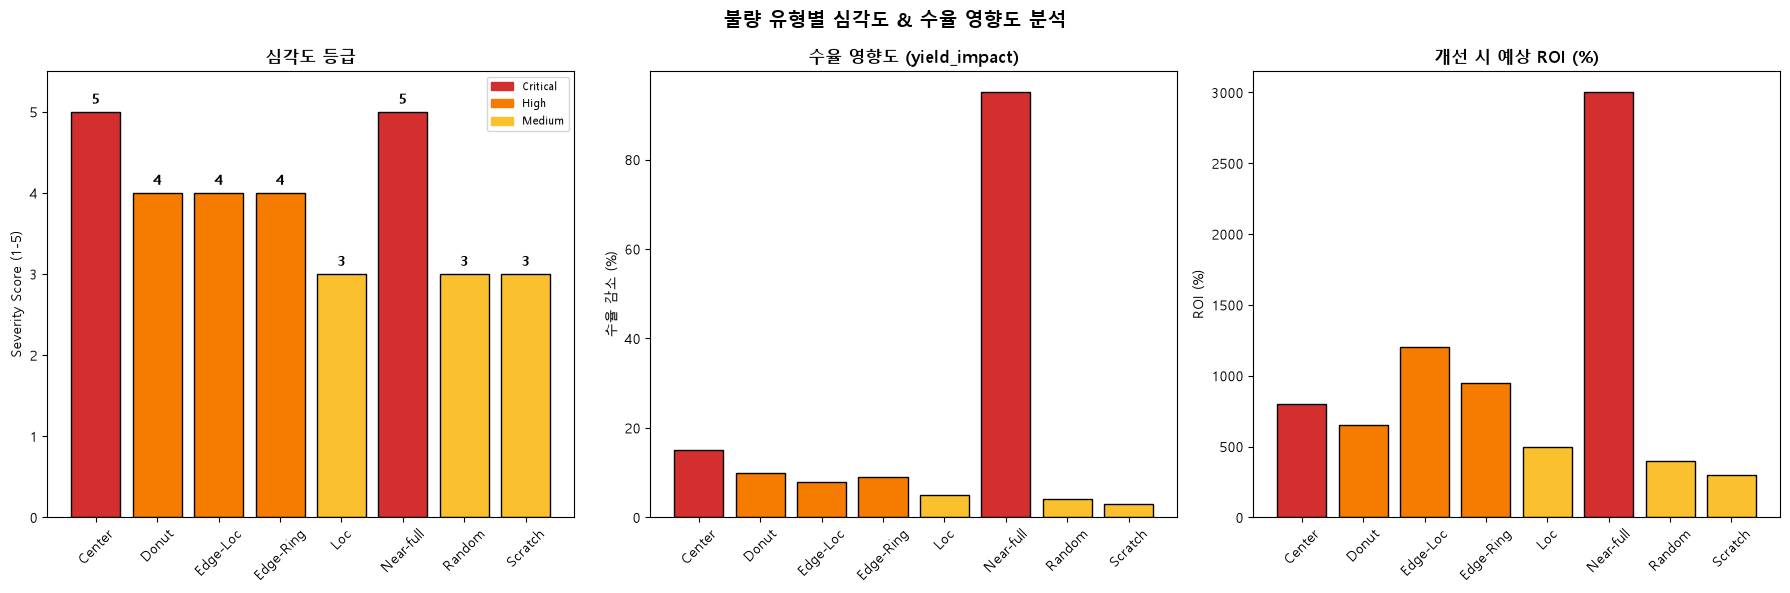

저장: analysis/defect_severity_yield.png


In [25]:
defect_classes = [c for c in CLASS_NAMES if c != 'none']
severity_scores = [MECHANISMS[c]['severity_score']  for c in defect_classes]
yield_impacts   = [MECHANISMS[c]['yield_impact']     for c in defect_classes]
roi_values      = [MECHANISMS[c]['estimated_roi_pct'] for c in defect_classes]

severity_colors = {
    5: '#D32F2F',  # Critical — 빨강
    4: '#F57C00',  # High — 주황
    3: '#FBC02D',  # Medium — 노랑
    2: '#388E3C',  # Low — 초록
}
bar_colors = [severity_colors[s] for s in severity_scores]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('불량 유형별 심각도 & 수율 영향도 분석', fontsize=14, fontweight='bold')

# 심각도 점수
bars = axes[0].bar(defect_classes, severity_scores, color=bar_colors, edgecolor='black')
axes[0].set_title('심각도 등급', fontweight='bold')
axes[0].set_ylabel('Severity Score (1-5)')
axes[0].set_ylim(0, 5.5)
axes[0].tick_params(axis='x', rotation=45)
for bar, score in zip(bars, severity_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(score), ha='center', fontweight='bold')

patches = [
    mpatches.Patch(color='#D32F2F', label='Critical'),
    mpatches.Patch(color='#F57C00', label='High'),
    mpatches.Patch(color='#FBC02D', label='Medium'),
]
axes[0].legend(handles=patches, loc='upper right', fontsize=8)

# 수율 영향도
axes[1].bar(defect_classes, [yi * 100 for yi in yield_impacts], color=bar_colors, edgecolor='black')
axes[1].set_title('수율 영향도 (yield_impact)', fontweight='bold')
axes[1].set_ylabel('수율 감소 (%)')
axes[1].tick_params(axis='x', rotation=45)

# ROI 예상치
axes[2].bar(defect_classes, roi_values, color=bar_colors, edgecolor='black')
axes[2].set_title('개선 시 예상 ROI (%)', fontweight='bold')
axes[2].set_ylabel('ROI (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'defect_severity_yield.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장: analysis/defect_severity_yield.png')

## 9. 공정 단계별 불량 분류 맵

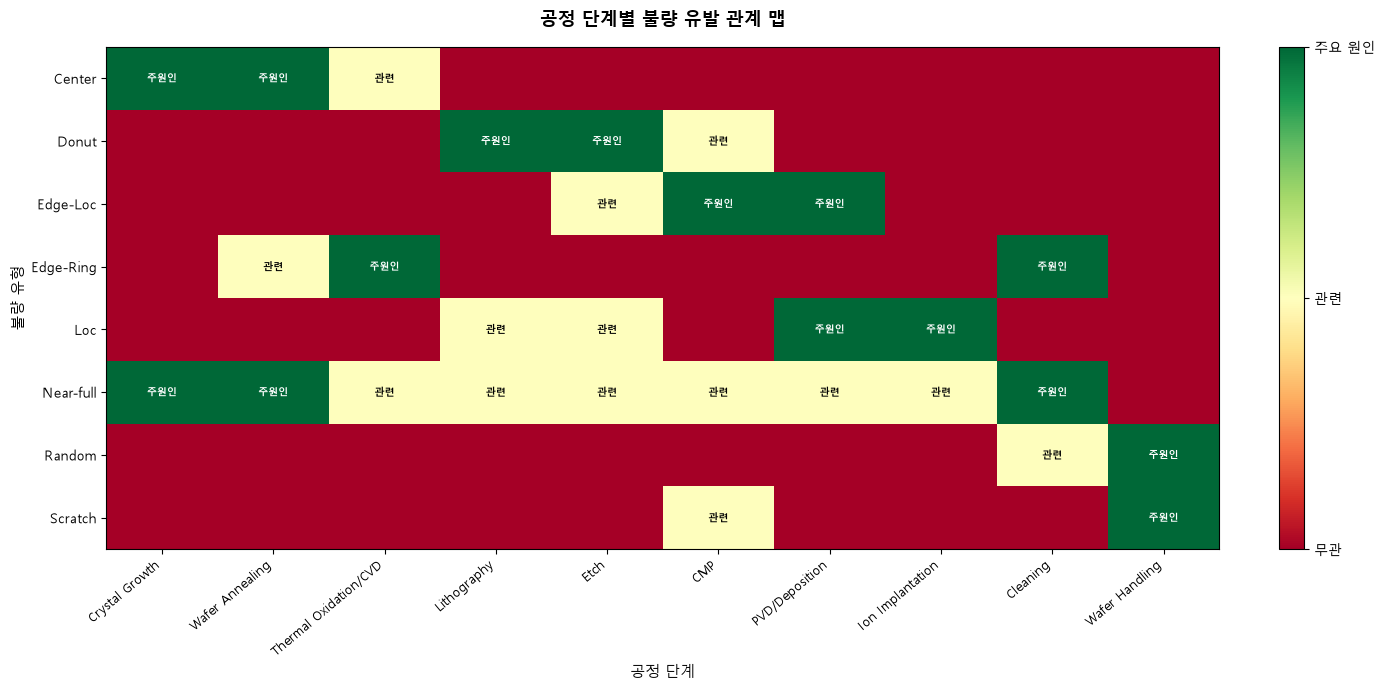

저장: analysis/process_defect_relation_map.png


In [26]:
# 공정 단계 × 불량 유형 매트릭스
process_stages = [
    'Crystal Growth',
    'Wafer Annealing',
    'Thermal Oxidation/CVD',
    'Lithography',
    'Etch',
    'CMP',
    'PVD/Deposition',
    'Ion Implantation',
    'Cleaning',
    'Wafer Handling'
]

# 각 공정이 각 불량 유형에 얼마나 관련되는지 (0=무관, 1=관련, 2=주요원인)
relation_matrix = {
    'Center':    [2, 2, 1, 0, 0, 0, 0, 0, 0, 0],
    'Donut':     [0, 0, 0, 2, 2, 1, 0, 0, 0, 0],
    'Edge-Loc':  [0, 0, 0, 0, 1, 2, 2, 0, 0, 0],
    'Edge-Ring': [0, 1, 2, 0, 0, 0, 0, 0, 2, 0],
    'Loc':       [0, 0, 0, 1, 1, 0, 2, 2, 0, 0],
    'Near-full': [2, 2, 1, 1, 1, 1, 1, 1, 2, 0],
    'Random':    [0, 0, 0, 0, 0, 0, 0, 0, 1, 2],
    'Scratch':   [0, 0, 0, 0, 0, 1, 0, 0, 0, 2],
}

matrix_arr = np.array([relation_matrix[c] for c in defect_classes])

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(matrix_arr, cmap='RdYlGn', vmin=0, vmax=2, aspect='auto')

ax.set_xticks(range(len(process_stages)))
ax.set_xticklabels(process_stages, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(defect_classes)))
ax.set_yticklabels(defect_classes, fontsize=10)

for i in range(len(defect_classes)):
    for j in range(len(process_stages)):
        val = matrix_arr[i, j]
        label = {0: '', 1: '관련', 2: '주원인'}[val]
        if label:
            ax.text(j, i, label, ha='center', va='center', fontsize=7, fontweight='bold',
                    color='white' if val == 2 else 'black')

cbar = plt.colorbar(im, ax=ax, fraction=0.025)
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['무관', '관련', '주요 원인'])

ax.set_title('공정 단계별 불량 유발 관계 맵', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('공정 단계', fontsize=11)
ax.set_ylabel('불량 유형', fontsize=11)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / 'process_defect_relation_map.png', dpi=120, bbox_inches='tight')
plt.show()
print('저장: analysis/process_defect_relation_map.png')

## 10. DefectAnalyzer 클래스 구현

In [27]:
defect_analyzer_code = '''
import json
import numpy as np
from pathlib import Path


class DefectAnalyzer:
    """불량 메타데이터 기반 분석 클래스 — Step 10~12 공통 사용"""

    def __init__(self, metadata_path):
        path = Path(metadata_path)
        if not path.exists():
            raise FileNotFoundError(f"메타데이터 파일 없음: {path}")
        with open(path, 'r', encoding='utf-8') as f:
            self.metadata = json.load(f)
        self.classes = list(self.metadata.keys())

    def get_mechanism(self, defect_class: str) -> str:
        self._validate(defect_class)
        return self.metadata[defect_class]['physical_mechanism']

    def get_process_stage(self, defect_class: str) -> str:
        self._validate(defect_class)
        return self.metadata[defect_class]['primary_process_stage']

    def get_critical_parameters(self, defect_class: str) -> list:
        self._validate(defect_class)
        return self.metadata[defect_class]['critical_parameters']

    def get_severity(self, defect_class: str) -> str:
        self._validate(defect_class)
        return self.metadata[defect_class]['severity_level']

    def get_severity_score(self, defect_class: str) -> int:
        self._validate(defect_class)
        return self.metadata[defect_class]['severity_score']

    def get_remediation(self, defect_class: str) -> str:
        self._validate(defect_class)
        return self.metadata[defect_class]['remediation']

    def predict_yield_loss(self, defect_class: str, defect_rate: float) -> float:
        """불량 발생률 × 수율 영향도 → 예상 수율 손실"""
        self._validate(defect_class)
        yield_impact = self.metadata[defect_class]['yield_impact']
        return float(defect_rate * yield_impact)

    def get_roi_estimate(self, defect_class: str) -> float:
        self._validate(defect_class)
        return self.metadata[defect_class]['estimated_roi_pct']

    def prioritize_defects(self, detected_classes: list) -> list:
        """검출된 불량 리스트를 심각도 기준으로 정렬"""
        scored = [
            (cls, self.get_severity_score(cls))
            for cls in detected_classes
            if cls in self.metadata and cls != 'none'
        ]
        return [cls for cls, _ in sorted(scored, key=lambda x: x[1], reverse=True)]

    def generate_report(self, defect_class: str, defect_rate: float = 0.0) -> dict:
        """단일 불량에 대한 분석 리포트 딕셔너리 반환"""
        self._validate(defect_class)
        meta = self.metadata[defect_class]
        return {
            'defect_class':       defect_class,
            'korean_name':        meta.get('korean_name', ''),
            'physical_mechanism': meta['physical_mechanism'],
            'process_stage':      meta['primary_process_stage'],
            'severity':           meta['severity_level'],
            'severity_score':     meta['severity_score'],
            'yield_loss_pct':     self.predict_yield_loss(defect_class, defect_rate) * 100,
            'estimated_roi_pct':  meta['estimated_roi_pct'],
            'critical_parameters': meta['critical_parameters'],
            'remediation':        meta['remediation'],
            'spatial_evidence':   meta.get('spatial_evidence', {})
        }

    def batch_report(self, predictions: list, defect_rates: dict = None) -> list:
        """배치 예측 결과 → 리포트 리스트 (우선순위 정렬)"""
        unique = list(set(predictions))
        prioritized = self.prioritize_defects(unique)
        reports = []
        for cls in prioritized:
            rate = defect_rates.get(cls, 0.0) if defect_rates else 0.0
            reports.append(self.generate_report(cls, rate))
        return reports

    def _validate(self, defect_class: str):
        if defect_class not in self.metadata:
            raise ValueError(f"알 수 없는 불량 클래스: {defect_class}. 유효: {self.classes}")
'''

src_path = SRC_DIR / 'defect_analyzer.py'
with open(src_path, 'w', encoding='utf-8') as f:
    f.write(defect_analyzer_code.strip())

print(f'저장: {src_path}')

저장: c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\src\defect_analyzer.py


## 11. DefectAnalyzer 동작 검증

In [28]:
import sys
sys.path.insert(0, str(SRC_DIR))
from defect_analyzer import DefectAnalyzer

analyzer = DefectAnalyzer(CONFIGS_DIR / 'defect_metadata.json')

# 테스트 케이스
print('=== DefectAnalyzer 동작 검증 ===')
print(f'\n[Center 불량 리포트]')
report = analyzer.generate_report('Center', defect_rate=0.02)
for k, v in report.items():
    if k not in ('critical_parameters', 'spatial_evidence'):
        print(f'  {k}: {v}')

print(f'\n[우선순위 정렬 테스트]')
detected = ['Random', 'Center', 'Near-full', 'Scratch', 'Edge-Loc']
prioritized = analyzer.prioritize_defects(detected)
print(f'  입력: {detected}')
print(f'  정렬: {prioritized}')

print(f'\n[수율 손실 예측]')
for cls in ['Near-full', 'Center', 'Edge-Ring']:
    loss = analyzer.predict_yield_loss(cls, defect_rate=0.01)
    print(f'  {cls:<12}: {loss*100:.3f}% 예상 손실 (발생률 1%)')

=== DefectAnalyzer 동작 검증 ===

[Center 불량 리포트]
  defect_class: Center
  korean_name: 중심 불량
  physical_mechanism: 웨이퍼 중심부 결정 결함 또는 열처리 불균일. 산소 석출물(SiO2)이 중심에 집중 생성되어 게이트 산화막 품질 저하를 유발
  process_stage: Wafer Preparation / Thermal Annealing
  severity: Critical
  severity_score: 5
  yield_loss_pct: 0.3
  estimated_roi_pct: 800
  remediation: 냉각 속도 제어 최적화, 산소 농도 타겟 재설정, RTP 온도 균일도 개선

[우선순위 정렬 테스트]
  입력: ['Random', 'Center', 'Near-full', 'Scratch', 'Edge-Loc']
  정렬: ['Center', 'Near-full', 'Edge-Loc', 'Random', 'Scratch']

[수율 손실 예측]
  Near-full   : 0.950% 예상 손실 (발생률 1%)
  Center      : 0.150% 예상 손실 (발생률 1%)
  Edge-Ring   : 0.090% 예상 손실 (발생률 1%)


## 12. 산출물 저장 — 불량 메커니즘 분석 리포트

In [29]:
# ── Markdown 리포트 생성 ──
severity_map = {'Critical': '🔴', 'High': '🟠', 'Medium': '🟡', 'Low': '🟢', 'None': '⚪'}

lines = [
    '# WM-811K 웨이퍼 불량 메커니즘 분석 리포트',
    '',
    '**생성일:** (자동 생성)  ',
    '**데이터:** WM-811K (172,950개 레이블 샘플)  ',
    '**분석 대상:** 9가지 불량 패턴의 물리적 원인 규명',
    '',
    '---',
    '',
    '## 클래스별 심각도 요약',
    '',
    '| 클래스 | 한국어명 | 심각도 | 수율 영향 | 주요 공정 | 예상 ROI |',
    '|--------|--------|--------|----------|----------|--------|',
]

for cls in CLASS_NAMES:
    m = MECHANISMS[cls]
    sev_icon = severity_map.get(m['severity_level'], '')
    roi = f"{m['estimated_roi_pct']}%" if m['estimated_roi_pct'] else 'N/A'
    lines.append(
        f"| {cls} | {m['korean_name']} | {sev_icon} {m['severity_level']} "
        f"| {m['yield_impact']*100:.0f}% | {m['primary_process_stage'][:30]} | {roi} |"
    )

lines += ['', '---', '', '## 상세 메커니즘 분석', '']

for cls in DEFECT_CLASSES:
    m = MECHANISMS[cls]
    sev_icon = severity_map.get(m['severity_level'], '')
    spatial = m.get('spatial_evidence', {})

    lines += [
        f'### {sev_icon} {cls} ({m["korean_name"]})',
        '',
        f'**물리적 원인:** {m["physical_mechanism"]}',
        '',
        f'**주요 공정 단계:** {m["primary_process_stage"]}',
        f'**관련 장비:** {", ".join(m["equipment_involved"])}',
        f'**심각도:** {m["severity_level"]} (점수: {m["severity_score"]}/5)',
        f'**수율 영향도:** {m["yield_impact"]*100:.0f}%',
        f'**예상 ROI:** {m["estimated_roi_pct"]}%' if m['estimated_roi_pct'] else '',
        '',
        '**핵심 파라미터:**',
    ]
    for p in m['critical_parameters']:
        lines.append(f'- `{p["name"]}` ({p["unit"]}): 정상범위 {p["normal_range"]} — {p["criticality"]}')

    if spatial:
        lines += [
            '',
            '**공간 분포 증거 (실측):',
            f'- 중심 집중도: {spatial.get("center_ratio", 0):.3f}',
            f'- 에지 집중도: {spatial.get("edge_ratio", 0):.3f}',
            f'- 불량 밀도: {spatial.get("defect_density", 0):.4f}',
        ]

    lines += [
        '',
        f'**처방:** {m["remediation"]}',
        '',
        '---',
        ''
    ]

report_text = '\n'.join(lines)
report_path = DOCS_DIR / 'defect_mechanism_analysis.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_text)

print(f'저장: {report_path}')
print(f'파일 크기: {report_path.stat().st_size / 1024:.1f} KB')

저장: c:\Users\naisk\Desktop\하이닉스 대비\웨이퍼 불량 분석\docs\defect_mechanism_analysis.md
파일 크기: 8.7 KB


In [30]:
# ── 최종 산출물 확인 ──
outputs = [
    CONFIGS_DIR  / 'defect_metadata.json',
    SRC_DIR      / 'defect_analyzer.py',
    DOCS_DIR     / 'defect_mechanism_analysis.md',
    ANALYSIS_DIR / 'defect_sample_gallery.png',
    ANALYSIS_DIR / 'defect_spatial_heatmaps.png',
    ANALYSIS_DIR / 'spatial_distribution_metrics.png',
    ANALYSIS_DIR / 'defect_severity_yield.png',
    ANALYSIS_DIR / 'process_defect_relation_map.png',
]

print('\n=== Step 9 산출물 목록 ===')
all_ok = True
for p in outputs:
    exists = p.exists()
    size = f'{p.stat().st_size/1024:.1f}KB' if exists else '-'
    status = '✅' if exists else '❌'
    print(f'{status} {p.relative_to(ROOT)}  ({size})')
    if not exists:
        all_ok = False

print(f'\n결과: {"전체 완료" if all_ok else "일부 누락"}')
print('\nStep 9 완료 → Step 10 (공정 파라미터 상관관계 분석) 진행 가능')


=== Step 9 산출물 목록 ===
✅ configs\defect_metadata.json  (13.2KB)
✅ src\defect_analyzer.py  (3.9KB)
✅ docs\defect_mechanism_analysis.md  (8.7KB)
✅ analysis\defect_sample_gallery.png  (52.1KB)
✅ analysis\defect_spatial_heatmaps.png  (552.2KB)
✅ analysis\spatial_distribution_metrics.png  (64.7KB)
✅ analysis\defect_severity_yield.png  (69.0KB)
✅ analysis\process_defect_relation_map.png  (70.5KB)

결과: 전체 완료

Step 9 완료 → Step 10 (공정 파라미터 상관관계 분석) 진행 가능
